In [1]:
import pandas as pd
df=pd.read_csv("Final_Transaction_Purchase.csv")
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,Pack_Size,Brand,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,NATURAL CHIP COMPNY SEASALT175G,2,6.0,175.0,NATURAL CHIP,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCS NACHO CHEESE 175G,3,6.3,175.0,CCS,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,SMITHS CRINKLE CUT CHIPS CHICKEN 170G,2,2.9,170.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,SMITHS CHIP THINLY S/CREAM&ONION 175G,5,15.0,175.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,KETTLE TORTILLA CHPSHNY&JLPNO CHILI 150G,3,13.8,150.0,KETTLE,MIDAGE SINGLES/COUPLES,Budget


### We analyzed total sales, quantity sold, and average transaction value to understand business performance.

In [2]:
#metrics

#total sales
total_sales=df["TOT_SALES"].sum()

#total product quantity
total_prod=df["PROD_QTY"].sum()

#total customer
total_customer=df["LYLTY_CARD_NBR"].count()

#averages sales
average_sales=df["TOT_SALES"].mean()

In [3]:
print(f"Total sales : {total_sales}")
print(f"Total Product Quantity : {total_prod}")
print(f"Total Customer : {total_customer}")
print(f"Average Sales : {average_sales}")

Total sales : 1934408.9999999998
Total Product Quantity : 505122
Total Customer : 264835
Average Sales : 7.3042045046916


In [4]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,Pack_Size,Brand,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,NATURAL CHIP COMPNY SEASALT175G,2,6.0,175.0,NATURAL CHIP,YOUNG SINGLES/COUPLES,Premium
1,2019-05-14,1,1307,348,66,CCS NACHO CHEESE 175G,3,6.3,175.0,CCS,MIDAGE SINGLES/COUPLES,Budget
2,2019-05-20,1,1343,383,61,SMITHS CRINKLE CUT CHIPS CHICKEN 170G,2,2.9,170.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-17,2,2373,974,69,SMITHS CHIP THINLY S/CREAM&ONION 175G,5,15.0,175.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget
4,2018-08-18,2,2426,1038,108,KETTLE TORTILLA CHPSHNY&JLPNO CHILI 150G,3,13.8,150.0,KETTLE,MIDAGE SINGLES/COUPLES,Budget


In [5]:
# find who is buying the most chips

high_sales=df.groupby("LIFESTAGE")["TOT_SALES"].sum().sort_values(ascending=False)

In [6]:
print(high_sales)

LIFESTAGE
OLDER SINGLES/COUPLES     402420.75
RETIREES                  366470.90
OLDER FAMILIES            353767.20
YOUNG FAMILIES            316160.10
YOUNG SINGLES/COUPLES     260405.30
MIDAGE SINGLES/COUPLES    184751.30
NEW FAMILIES               50433.45
Name: TOT_SALES, dtype: float64


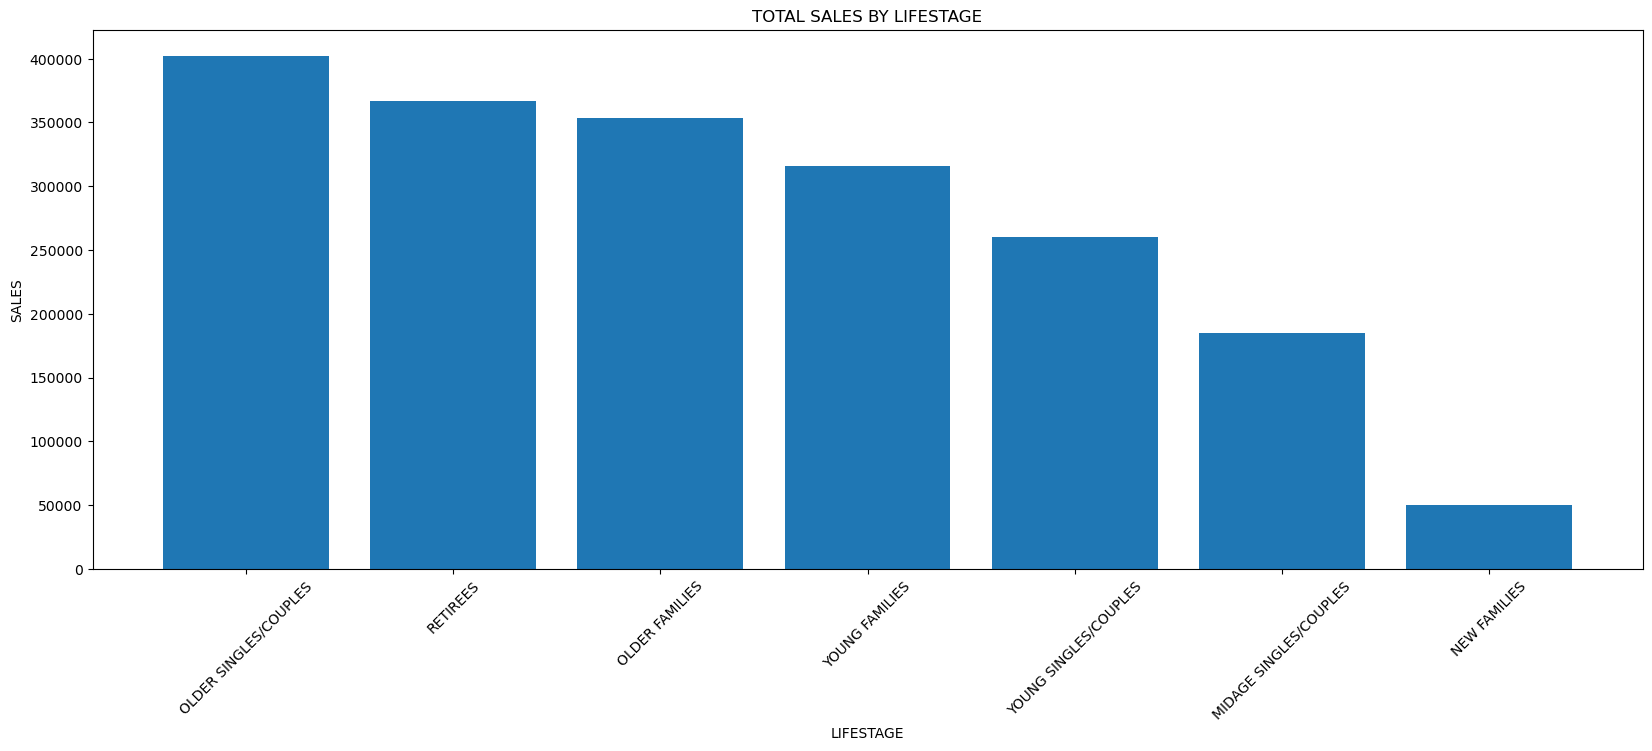

In [46]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,7))
plt.bar(high_sales.index, high_sales.values)

plt.xlabel("LIFESTAGE")
plt.ylabel("SALES")
plt.title("TOTAL SALES BY LIFESTAGE")

plt.xticks(rotation=45)

plt.savefig("lifestage_sales.png")

## Sales by Lifestage – Insights

## 1.Older Singles/Couples contribute the highest sales (~402K), indicating they are the most valuable customer group in terms of chip purchases.
## 2.Retirees (~366K) and Older Families (~353K) also generate strong sales, showing that older demographics have higher spending power or consistent purchasing behavior.
## 3.Young Families (~316K) perform moderately well, likely due to larger household consumption.
## 4.Young Singles/Couples (~260K) and Midage Singles/Couples (~184K) contribute comparatively lower sales, suggesting lower spending or less frequent purchases.
## 5.New Families (~50K) have the lowest sales, indicating either a smaller segment size or lower purchasing capacity.

In [67]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,Pack_Size,Brand,LIFESTAGE,PREMIUM_CUSTOMER,pack_category
0,2018-10-17,1,1000,1,5,NATURAL CHIP COMPNY SEASALT175G,2,6.0,175.0,NATURAL CHIP,YOUNG SINGLES/COUPLES,Premium,100-200g
1,2019-05-14,1,1307,348,66,CCS NACHO CHEESE 175G,3,6.3,175.0,CCS,MIDAGE SINGLES/COUPLES,Budget,100-200g
2,2019-05-20,1,1343,383,61,SMITHS CRINKLE CUT CHIPS CHICKEN 170G,2,2.9,170.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget,100-200g
3,2018-08-17,2,2373,974,69,SMITHS CHIP THINLY S/CREAM&ONION 175G,5,15.0,175.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget,100-200g
4,2018-08-18,2,2426,1038,108,KETTLE TORTILLA CHPSHNY&JLPNO CHILI 150G,3,13.8,150.0,KETTLE,MIDAGE SINGLES/COUPLES,Budget,100-200g


In [68]:
premium_sales=df.groupby("PREMIUM_CUSTOMER")["TOT_SALES"].sum().sort_values(ascending=False)
premium_sales

PREMIUM_CUSTOMER
Mainstream    750744.50
Budget        676211.55
Premium       507452.95
Name: TOT_SALES, dtype: float64

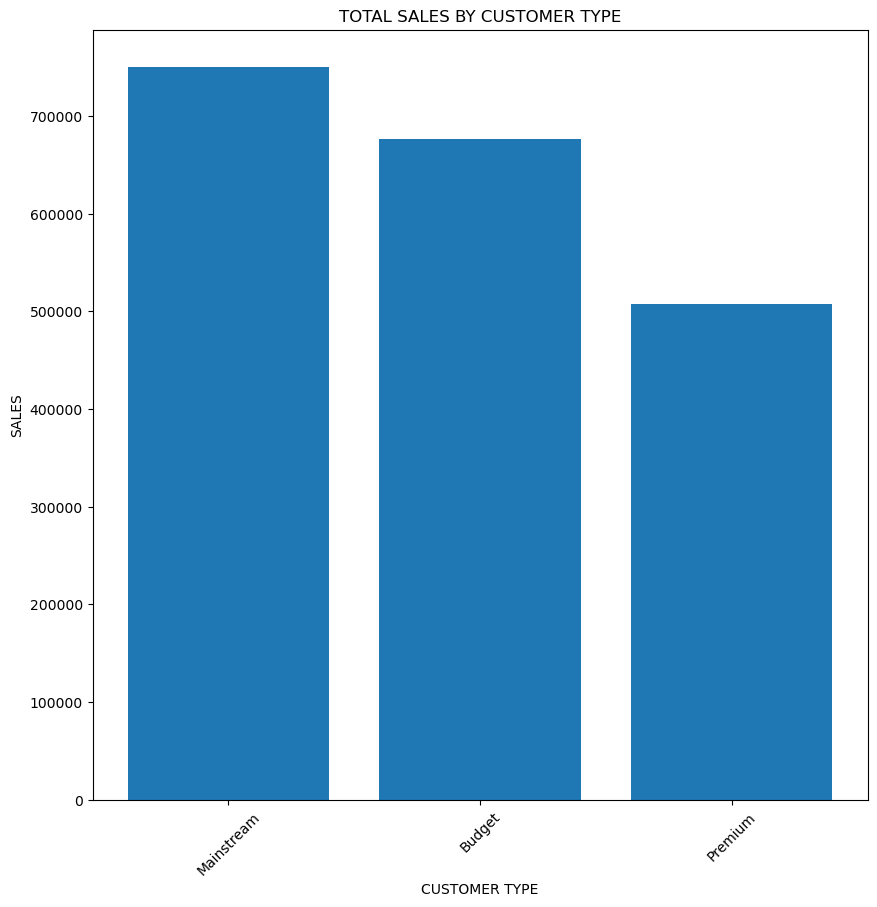

In [69]:
plt.figure(figsize=(10,10))
plt.bar(premium_sales.index, premium_sales.values)

plt.xlabel("CUSTOMER TYPE")
plt.ylabel("SALES")
plt.title("TOTAL SALES BY CUSTOMER TYPE")
plt.xticks(rotation=45)

plt.savefig("customertype_sales.png")

## Sales by Customer Type – Insights
## 1.Mainstream customers contribute the highest sales (~750K), indicating they form the largest and most impactful segment in overall chip purchases.
## 2.Budget customers (~676K) also generate strong revenue, showing that price-sensitive shoppers still account for a significant share of total sales.
## 3.Premium customers (~507K) contribute the least among the three segments, suggesting either a smaller customer base or less frequent chip purchases despite potentially higher-priced choices.

In [70]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,Pack_Size,Brand,LIFESTAGE,PREMIUM_CUSTOMER,pack_category
0,2018-10-17,1,1000,1,5,NATURAL CHIP COMPNY SEASALT175G,2,6.0,175.0,NATURAL CHIP,YOUNG SINGLES/COUPLES,Premium,100-200g
1,2019-05-14,1,1307,348,66,CCS NACHO CHEESE 175G,3,6.3,175.0,CCS,MIDAGE SINGLES/COUPLES,Budget,100-200g
2,2019-05-20,1,1343,383,61,SMITHS CRINKLE CUT CHIPS CHICKEN 170G,2,2.9,170.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget,100-200g
3,2018-08-17,2,2373,974,69,SMITHS CHIP THINLY S/CREAM&ONION 175G,5,15.0,175.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget,100-200g
4,2018-08-18,2,2426,1038,108,KETTLE TORTILLA CHPSHNY&JLPNO CHILI 150G,3,13.8,150.0,KETTLE,MIDAGE SINGLES/COUPLES,Budget,100-200g


In [71]:
##let us see which combine customer give more sales

sales_segment=df.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["TOT_SALES"].sum().sort_values(ascending=False)
sales_segment

LIFESTAGE               PREMIUM_CUSTOMER
OLDER FAMILIES          Budget              168363.25
YOUNG SINGLES/COUPLES   Mainstream          157621.60
RETIREES                Mainstream          155677.05
YOUNG FAMILIES          Budget              139345.85
OLDER SINGLES/COUPLES   Budget              136769.80
                        Mainstream          133393.80
                        Premium             132257.15
RETIREES                Budget              113147.80
OLDER FAMILIES          Mainstream          103445.55
RETIREES                Premium              97646.05
YOUNG FAMILIES          Mainstream           92788.75
MIDAGE SINGLES/COUPLES  Mainstream           90803.85
YOUNG FAMILIES          Premium              84025.50
OLDER FAMILIES          Premium              81958.40
YOUNG SINGLES/COUPLES   Budget               61141.60
MIDAGE SINGLES/COUPLES  Premium              58432.65
YOUNG SINGLES/COUPLES   Premium              41642.10
MIDAGE SINGLES/COUPLES  Budget           

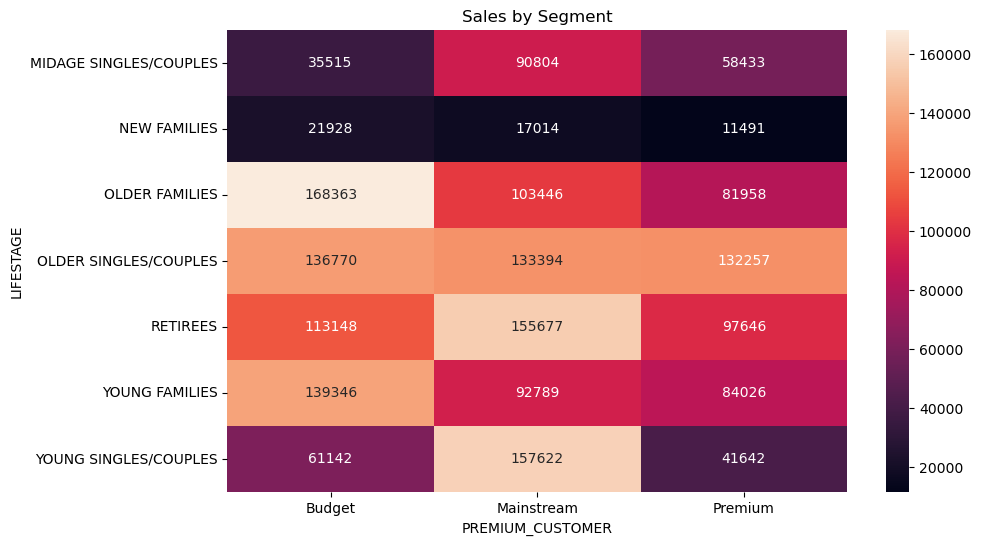

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = sales_segment.unstack()

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True, fmt=".0f")

plt.title("Sales by Segment")


plt.savefig("lifestage_customertype_sales.png")
plt.show()

## Sales by Customer Segment – Insights
## 1.Older Families (Budget) generate the highest sales (~168K), indicating that price-sensitive family households are a key revenue driver.
## 2.Young Singles/Couples (Mainstream) (~157K) and Retirees (Mainstream) (~155K) are also top contributors, showing strong spending from middle-tier customers across different age groups.
## 3.Young Families (Budget) (~139K) and Older Singles/Couples across all segments (~132K–136K) contribute consistently, highlighting their importance as stable revenue-generating groups.
## 4.Retirees show balanced spending across Budget, Mainstream, and Premium segments, suggesting diversified purchasing behavior.
## 5.Midage Singles/Couples and Young Singles (Budget/Premium) contribute comparatively lower sales, indicating lower engagement or spending capacity.
## 6.New Families contribute the least across all segments (~11K–21K), making them the smallest and least impactful group in terms of chip purchases.

In [73]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,Pack_Size,Brand,LIFESTAGE,PREMIUM_CUSTOMER,pack_category
0,2018-10-17,1,1000,1,5,NATURAL CHIP COMPNY SEASALT175G,2,6.0,175.0,NATURAL CHIP,YOUNG SINGLES/COUPLES,Premium,100-200g
1,2019-05-14,1,1307,348,66,CCS NACHO CHEESE 175G,3,6.3,175.0,CCS,MIDAGE SINGLES/COUPLES,Budget,100-200g
2,2019-05-20,1,1343,383,61,SMITHS CRINKLE CUT CHIPS CHICKEN 170G,2,2.9,170.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget,100-200g
3,2018-08-17,2,2373,974,69,SMITHS CHIP THINLY S/CREAM&ONION 175G,5,15.0,175.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget,100-200g
4,2018-08-18,2,2426,1038,108,KETTLE TORTILLA CHPSHNY&JLPNO CHILI 150G,3,13.8,150.0,KETTLE,MIDAGE SINGLES/COUPLES,Budget,100-200g


In [74]:
avg_spender=df.groupby(["LIFESTAGE","PREMIUM_CUSTOMER"])["TOT_SALES"].mean().sort_values(ascending=False)
avg_spender

LIFESTAGE               PREMIUM_CUSTOMER
MIDAGE SINGLES/COUPLES  Mainstream          7.647284
YOUNG SINGLES/COUPLES   Mainstream          7.558339
RETIREES                Premium             7.456174
OLDER SINGLES/COUPLES   Premium             7.449848
RETIREES                Budget              7.443445
OLDER SINGLES/COUPLES   Budget              7.430315
OLDER FAMILIES          Premium             7.322945
NEW FAMILIES            Mainstream          7.317806
                        Budget              7.297321
YOUNG FAMILIES          Budget              7.287201
OLDER SINGLES/COUPLES   Mainstream          7.282116
OLDER FAMILIES          Budget              7.269570
YOUNG FAMILIES          Premium             7.266756
OLDER FAMILIES          Mainstream          7.262395
RETIREES                Mainstream          7.252262
NEW FAMILIES            Premium             7.231655
YOUNG FAMILIES          Mainstream          7.189025
MIDAGE SINGLES/COUPLES  Premium             7.112056
     

Text(0.5, 1.0, 'Average Sales Segment')

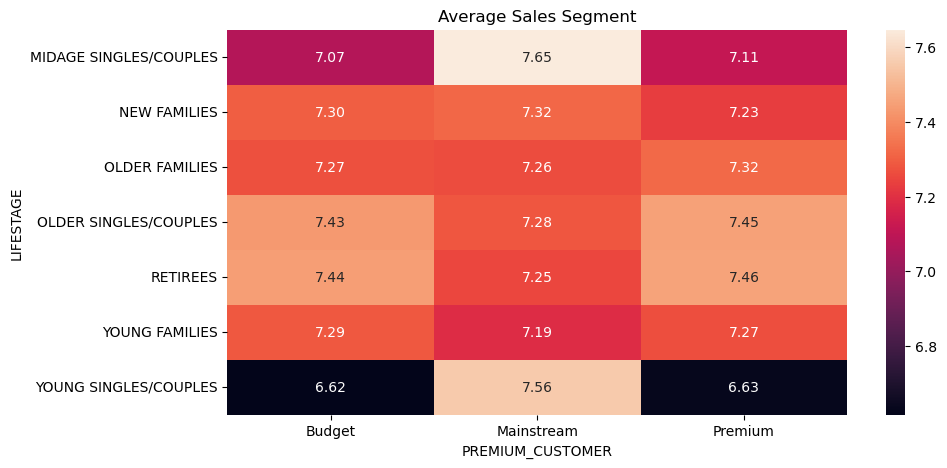

In [54]:
pivot1=avg_spender.unstack()

plt.figure(figsize=(10,5))

sns.heatmap(pivot1,annot=True,fmt=".2f")

plt.title("Average Sales Segment")

## Average Spend per Segment – Insights
## 1.Midage Singles/Couples (Mainstream) (~7.65) and Young Singles/Couples (Mainstream) (~7.56) have the highest average spend per transaction, indicating strong per-purchase value among mainstream single consumers.
## 2.Retirees and Older Singles/Couples in Premium and Budget segments (~7.43–7.45) also show consistently high spending, reflecting stable and relatively higher purchasing power.
## 3.Older Families (Premium) and New Families (Mainstream/Budget) (~7.29–7.32) demonstrate moderate spending, suggesting balanced but not top-tier transaction values.
## 4.Young Families across all segments (~7.18–7.29) show slightly lower average spend, possibly due to more frequent but smaller purchases.
## 5.Midage Singles/Couples (Budget/Premium) and Young Singles/Couples (especially Budget ~6.61 and Premium ~6.63) have the lowest average spend, indicating more price-sensitive behavior or smaller basket sizes.

##  --------------------------------------------------------------------------------------------

## Sales Drivers

In [55]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,Pack_Size,Brand,LIFESTAGE,PREMIUM_CUSTOMER,pack_category
0,2018-10-17,1,1000,1,5,NATURAL CHIP COMPNY SEASALT175G,2,6.0,175.0,NATURAL CHIP,YOUNG SINGLES/COUPLES,Premium,100-200g
1,2019-05-14,1,1307,348,66,CCS NACHO CHEESE 175G,3,6.3,175.0,CCS,MIDAGE SINGLES/COUPLES,Budget,100-200g
2,2019-05-20,1,1343,383,61,SMITHS CRINKLE CUT CHIPS CHICKEN 170G,2,2.9,170.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget,100-200g
3,2018-08-17,2,2373,974,69,SMITHS CHIP THINLY S/CREAM&ONION 175G,5,15.0,175.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget,100-200g
4,2018-08-18,2,2426,1038,108,KETTLE TORTILLA CHPSHNY&JLPNO CHILI 150G,3,13.8,150.0,KETTLE,MIDAGE SINGLES/COUPLES,Budget,100-200g


In [56]:
high_brand_sales=df.groupby("Brand")["TOT_SALES"].sum().sort_values(ascending=False)
high_brand_sales

Brand
KETTLE           390239.8
OTHER            221978.1
SMITHS           210070.8
DORITOS          201538.9
PRINGLES         177655.5
RED ROCK DELI     95046.0
THINS             88852.5
TWISTIES          81522.1
TOSTITOS          79789.6
INFUZIONS         76247.6
COBS              70569.8
TYRRELLS          51647.4
WOOLWORTHS        49343.6
GRAIN WAVES       43048.8
CHEEZELS          40029.9
CCS               18078.9
NATURAL CHIP      17265.0
CHEETOS           16884.5
SUNBITES           4600.2
Name: TOT_SALES, dtype: float64

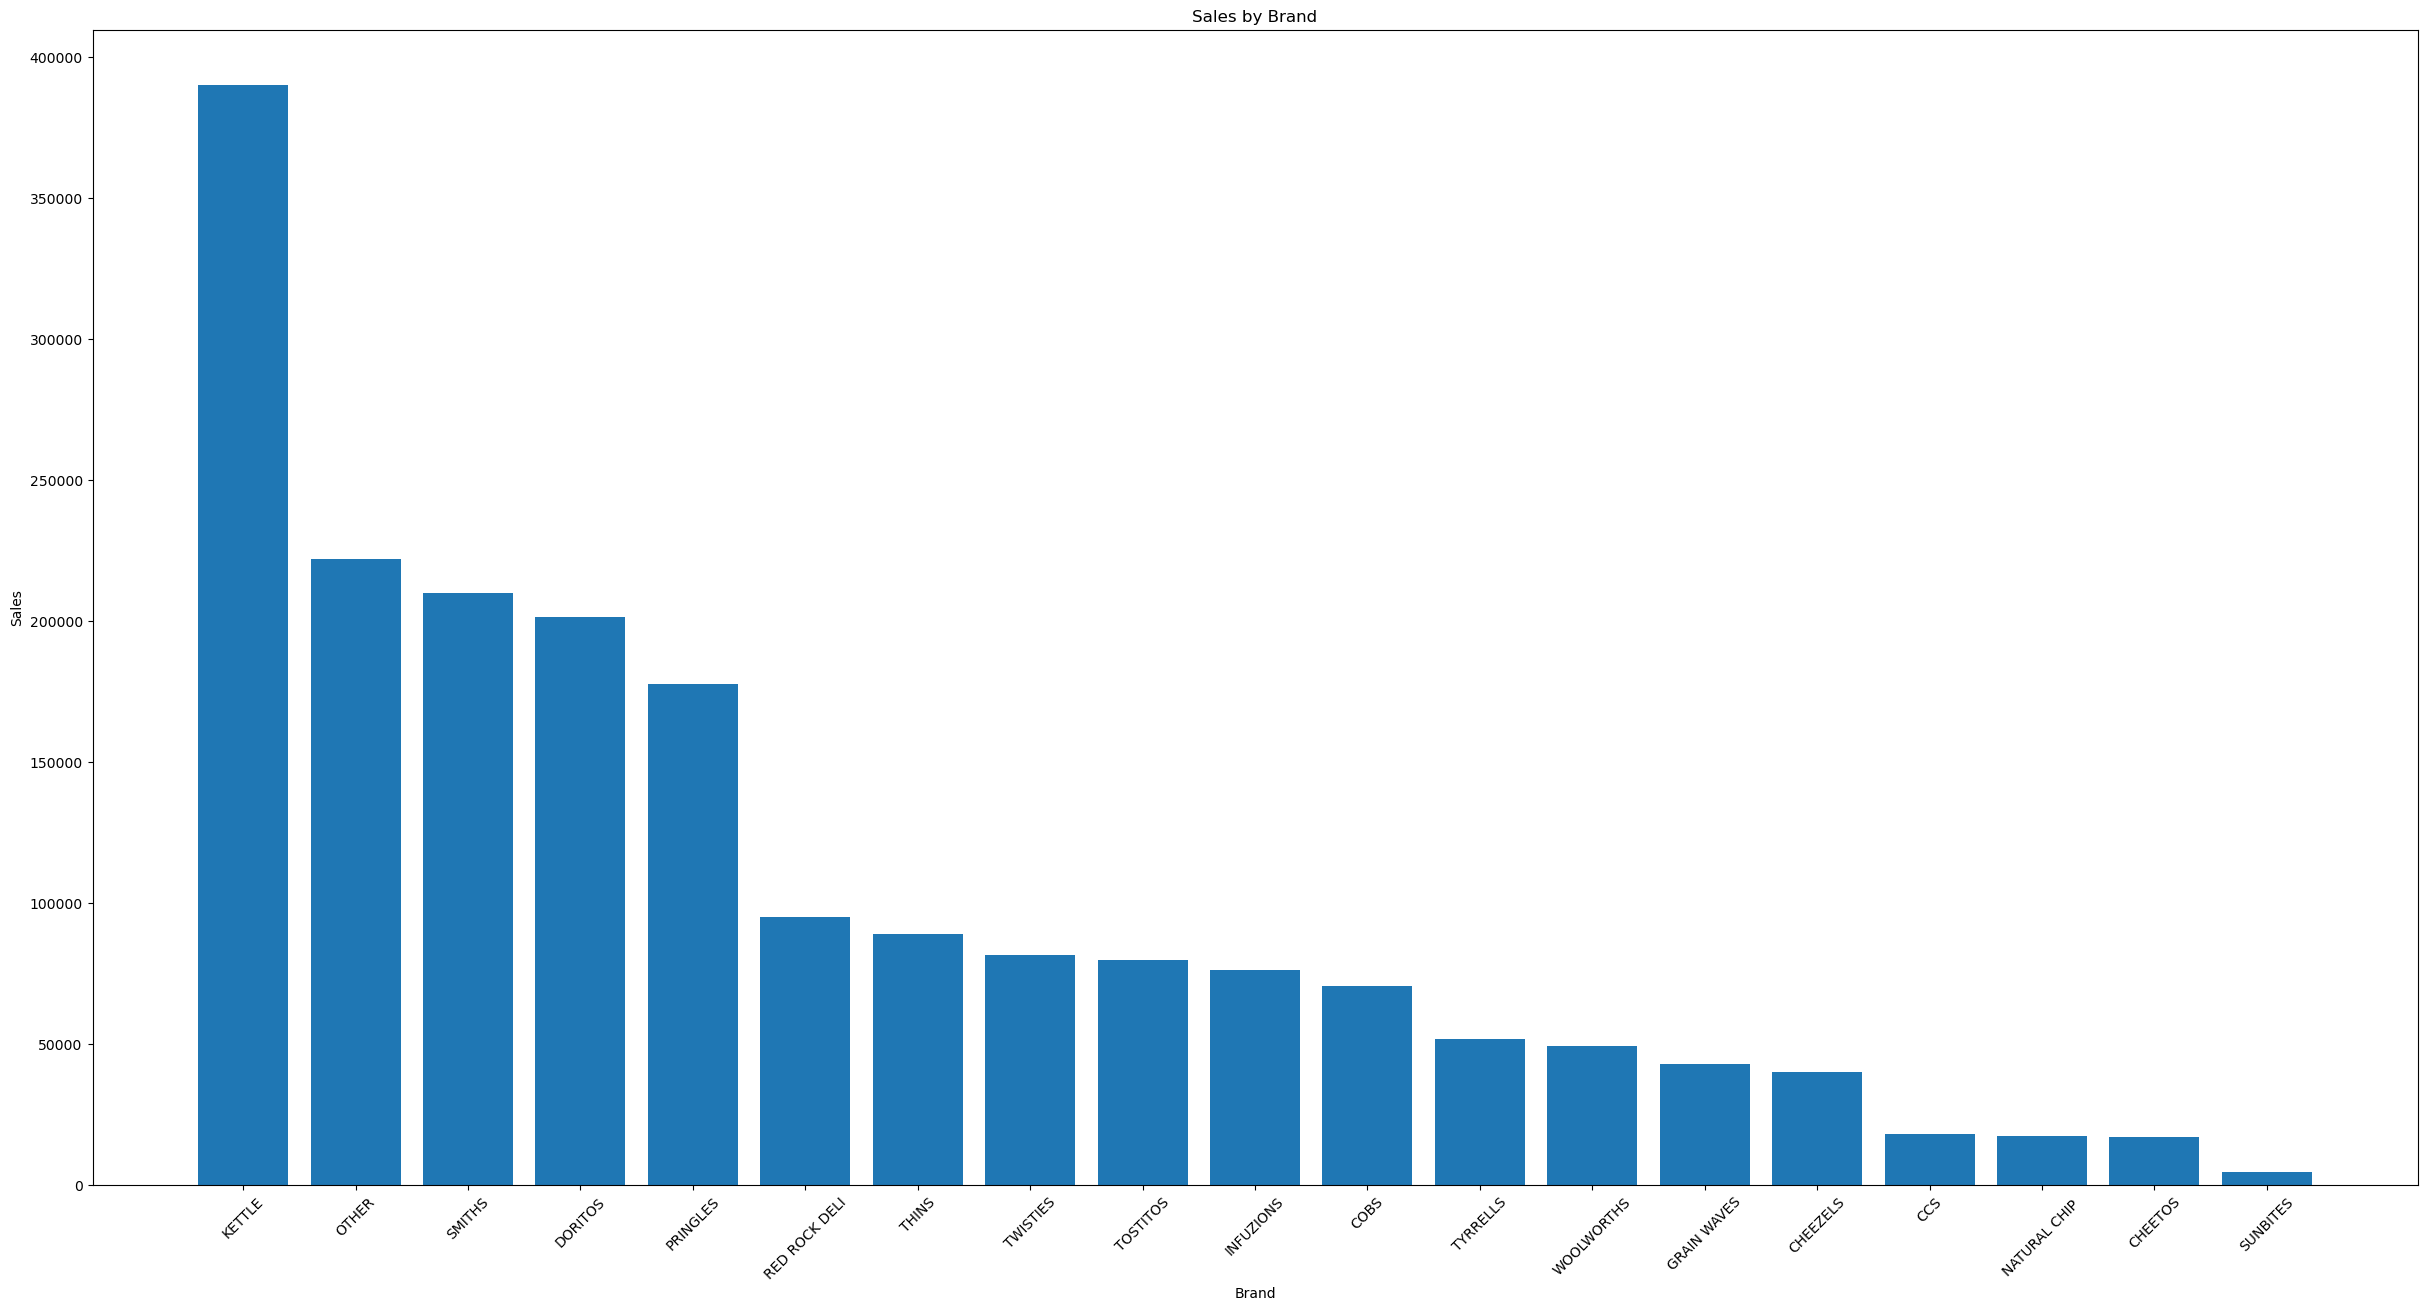

In [57]:
plt.figure(figsize=(30,15))

plt.bar(high_brand_sales.index,high_brand_sales.values)

plt.title("Sales by Brand")
plt.xlabel("Brand")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.savefig("brand_sales.png")

## Sales by Brand – Insights
## 1.KETTLE is the top-performing brand (~390K), making it the strongest driver of sales and a key contributor to overall revenue.
## 2.OTHER category (~222K) is the second highest, indicating that some products are still not fully classified and may need further cleaning for more accurate insights.
## 3.SMITHS (~210K), DORITOS (~201K), and PRINGLES (~177K) are major contributors, showing strong competition among leading chip brands.
## 4.Mid-tier brands like RED ROCK DELI, THINS, TWISTIES, TOSTITOS, and INFUZIONS (~75K–95K) also play an important role in overall sales, contributing consistently across the market.
## 5.Smaller brands such as COBS, TYRRELLS, and WOOLWORTHS (~49K–70K) contribute moderate sales, while GRAIN WAVES and CHEEZELS show relatively lower but stable performance.
## 6.Low-performing brands like CCS, NATURAL CHIP, CHEETOS, and SUNBITES (<20K) contribute minimal sales, indicating limited market impact.

In [58]:
df.head()

,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,Pack_Size,Brand,LIFESTAGE,PREMIUM_CUSTOMER,pack_category
0,2018-10-17,1,1000,1,5,NATURAL CHIP COMPNY SEASALT175G,2,6.0,175.0,NATURAL CHIP,YOUNG SINGLES/COUPLES,Premium,100-200g
1,2019-05-14,1,1307,348,66,CCS NACHO CHEESE 175G,3,6.3,175.0,CCS,MIDAGE SINGLES/COUPLES,Budget,100-200g
2,2019-05-20,1,1343,383,61,SMITHS CRINKLE CUT CHIPS CHICKEN 170G,2,2.9,170.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget,100-200g
3,2018-08-17,2,2373,974,69,SMITHS CHIP THINLY S/CREAM&ONION 175G,5,15.0,175.0,SMITHS,MIDAGE SINGLES/COUPLES,Budget,100-200g
4,2018-08-18,2,2426,1038,108,KETTLE TORTILLA CHPSHNY&JLPNO CHILI 150G,3,13.8,150.0,KETTLE,MIDAGE SINGLES/COUPLES,Budget,100-200g


In [59]:
df["Pack_Size"].unique()

array([175., 170., 150., 300., 330., 210., 270., 220., 125., 110., 134.,
       380., 180., 165., 135., 250., 200., 160., 190.,  90.,  70.])

In [60]:
pack_sales=df.groupby("Pack_Size")["TOT_SALES"].sum().sort_values(ascending=False)
pack_sales

Pack_Size
175.0    485431.4
150.0    304288.5
134.0    177655.5
110.0    162765.4
170.0    146673.0
330.0    136794.3
300.0    113330.6
165.0    101360.6
380.0     76719.6
270.0     55425.4
210.0     43048.8
250.0     26096.7
135.0     26090.4
200.0     16007.5
190.0     14412.9
160.0     10647.6
90.0       9676.4
180.0      8568.4
70.0       6852.0
220.0      6831.0
125.0      5733.0
Name: TOT_SALES, dtype: float64

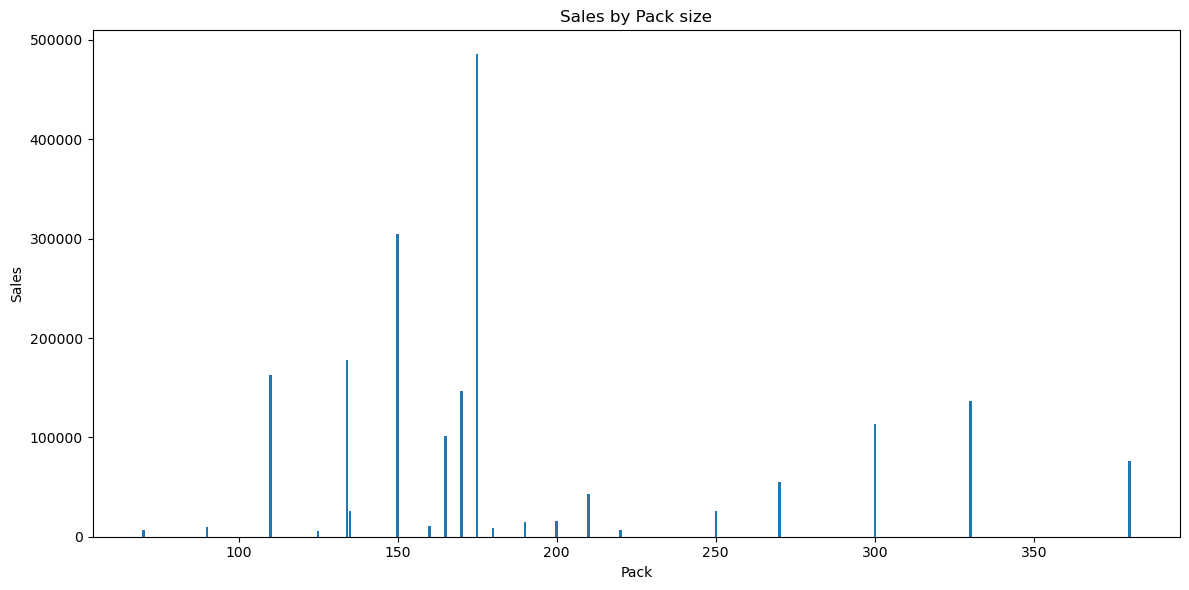

In [61]:
plt.figure(figsize=(12,6))

plt.bar(pack_sales.index,pack_sales.values)

plt.title("Sales by Pack size")
plt.xlabel("Pack")
plt.ylabel("Sales")

plt.tight_layout() 

## it doesnt give perfect visualization so we convert it into bins

In [62]:
bins=[0,100,200,300,400,500]
labels=["0-100g","100-200g","200-300g","300-400g","400-500g"]

df["pack_category"]=pd.cut(df["Pack_Size"],bins=bins,labels=labels)

In [63]:
pack_sales1=df.groupby("pack_category")["TOT_SALES"].sum().sort_values(ascending=False)
pack_sales1

C:\Users\jalal\AppData\Local\Temp\ipykernel_7748\294145246.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pack_sales1=df.groupby("pack_category")["TOT_SALES"].sum().sort_values(ascending=False)


pack_category
100-200g    1459634.2
200-300g     244732.5
300-400g     213513.9
0-100g        16528.4
400-500g          0.0
Name: TOT_SALES, dtype: float64

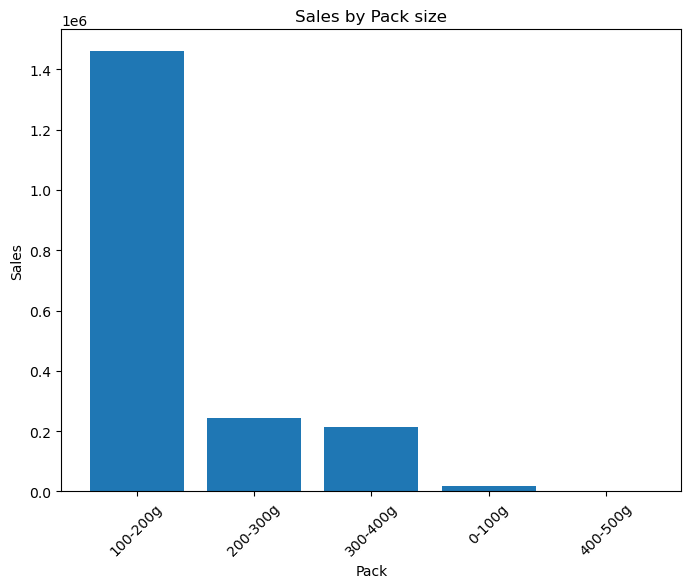

In [64]:
plt.figure(figsize=(8,6))

plt.bar(pack_sales1.index,pack_sales1.values)

plt.title("Sales by Pack size")
plt.xlabel("Pack")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.savefig("packsize_sales.png")

## Sales by Pack Size Category – Insights
## 1.The 100–200g pack size dominates sales (~1.46M), making it the most preferred choice among customers and the primary driver of revenue.
## 2.The 200–300g (~244K) and 300–400g (~213K) categories contribute moderately, indicating that larger packs are purchased but less frequently than mid-sized packs.
## 3.The 0–100g category (~16K) contributes very little, suggesting that smaller packs are not popular among customers.
## 4.The 400–500g category shows no sales, indicating either no products in this range or no demand.

## ----------------------------------------------------------------------------------------



## 🎯 Business Recommendations 

### 1. 🎯 Focus on High-Value Customer Segments

* Older Families (Budget) and Mainstream customers generate the highest sales
* These segments should be the **primary target for marketing campaigns**

👉 Action:

* Run targeted promotions and ads for these groups
* Offer combo deals for family consumption

---

### 2. 📦 Promote Medium Pack Sizes (100–200g)

* This pack size contributes the **highest sales**
* Customers prefer this size due to a balance of price and quantity

👉 Action:

* Increase visibility of 100–200g packs in stores
* Offer discounts or bundle offers on this category

---

### 3. 🏷️ Strengthen Top-Performing Brands

* Brands like **KETTLE, SMITHS, DORITOS, PRINGLES** drive most of the revenue

👉 Action:

* Ensure these brands are always well-stocked
* Use promotions, ads, and better shelf placement

---

### 4. 📉 Improve Low-Performing Segments

* New Families and some Budget/Premium segments contribute low sales

👉 Action:

* Introduce discounts or smaller trial packs
* Use targeted offers to increase engagement

---

### 5. 💰 Leverage Mainstream Customers for Volume Growth

* Mainstream customers contribute the **largest overall revenue**

👉 Action:

* Focus on affordable pricing strategies
* Provide value deals to increase purchase frequency

---

### 6. 📊 Opportunity for Larger Pack Sizes

* Larger packs (200g+) contribute moderate sales

👉 Action:

* Promote bulk-buy offers
* Target families who prefer buying in quantity


In [65]:
df.to_csv("final_data.csv", index=False)

In [66]:
high_sales.to_csv("sales_lifestage.csv")
premium_sales.to_csv("sales_premium.csv")
sales_segment.to_csv("sales_segment.csv")
high_brand_sales.to_csv("brand_sales.csv")
pack_sales1.to_csv("pack_sales.csv")

CONCLUSION:

The analysis shows that chip sales are primarily driven by mainstream and budget customers, especially older families. 
Medium pack sizes (100–200g) are the most popular and generate the highest revenue. 
Top brands like KETTLE, SMITHS, and DORITOS dominate the market.

Focusing on high-performing customer segments, optimizing pack sizes, and strengthening top brands will help maximize sales and business growth.